# Probing the Foundations of Test-Time Adaptation Under Resource Constraints 🚀 🧨

<p align="center">
Sidharrth Nagappan <br/>
University of Cambridge <br/>
sn666@cam.ac.uk
</p>

This mini-project is for L46: Principles of Machine Learning Systems at the University of Cambridge. For any questions, please email <sn666@cam.ac.uk>.

*Note: There are multiple notebooks in this project, often with many cells, and output diagrams. Since this may be difficult to navigate, this central notebook will serve as the unifying document that provides an overview of the project. It discusses the key ideas and provides links to the other notebooks as necessary.*

The goal of this project is to explore various methods for test-time adaptation, with a particular focus on optimising these methods for operation in low-resource settings and extreme conditions. Across a series of experiments, I want to understand:

1. If Test-Time Adaptation works in low-resource (pruned) settings, and understand the bidirectional impact of pruning on test-time adaptation and vice versa.
   
2. The visual and salient operation of test-time adaptation beyond the standard theoretical metrics outlined in academic papers.
 
3. State-of-the-art gradient based test-time adaptation methods, their limitations, and whether we can improve the state-of-the-art under resource constraints

<img src="./excalidraw_graphics/experiments.png" width="800">

The experiments are structured in an evolutionary manner, centered around the over-arching theme of test-time adaptation, but each explore different facets of the problem and different techniques. The project starts with probing the 2021 paper TENT, and ends with improving a 2024 state-of-the-art adaptation method known as FOA.

### Acknowledgements

While the majority of the code is written by me, for efficient reproduction of the primary algorithms, significant chunks have been borrowed from the original repositories of each of the papers:

1. TENT - https://github.com/DequanWang/tent
2. FOA - https://github.com/mr-eggplant/FOA
3. TTT - https://github.com/yueatsprograms/ttt_cifar_release

<!-- The full codebase of my project is available on GitHub along with this notebook, but I have included the most important results in this notebook for clarity and ease of understanding.  -->

For efficient structured and isomorphic pruning, I adapt and use algorithms from DepGraph - https://arxiv.org/abs/2301.12900 via their open-source implementation - https://github.com/VainF/Torch-Pruning. 

Salience Analysis uses the [pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam) library.

## Background

### What is test-time adaptation?

In the real world, models are trained on one distribution of data and tested on another. Test-time adaptation tries to find out if we can adapt the model to the test distribution at inference time, slowly, gradually and progressively by making small changes to the model. It could be thought of as a means of continuously training a model. Methods for test-time adaptation can be broadly classified into two categories:

1. **Gradient-based** - A parameter/gradient in the model is updated during TTA. Since there is a gradient "update", backpropagation is required. While gradient-based TTA can model, learn and remember very deep representations of the changing data distributions, it is computationally expensive to make these updates at inference time, regardless of the size of the update. 
2. **Gradient-free** - Model output probabilities / classifier weighting can be adjusted in a gradient-free manner without backpropagation. These methods are computationally cheaper, but they have a limited learning capacity, since they cannot exploit model feedback. 

### Method Comparison

There are various test-time adaptation methods in the literature. For this project, I have selected 3 representative methods from the options below:

1. **TTT** is a pioneering 2020 gradient-based method - TTT introduced the foundations of test-time adaptation and is the first to coin the term. It employs an auxiliary task that does self-supervised learning on the test data. Since it often requires updating entire models, **it is mainly an experimental method, and is not used in production systems**. I do, however, use it in combination with FOA in Experiment 3 to see if it can still add value. 
2. **TENT** is a 2021 gradient-based method - TENT is chosen, as it is the most fundamental and well-documented adaptation strategy, that depends on the fundamental principle of prediction entropy minimization.
3. **FOA** is a 2024 gradient-free method - It is widely considered the state-of-the-art as of 2024. It uses covariance-matrix adaptation and evolutionary computation to optimize augmented input prompts.

| Algorithm | Adaptation Strategy                                            | Updated Components                           | Type |
|-----------|----------------------------------------------------------------|----------------------------------------------|-------------------------------------|
| **TTT** (2020) ✅   | Auxiliary Task                      | All model parameters | Gradient-Based                                  |
| **TENT**(2021) ✅  | Minimizes prediction entropy on test data                      | Model parameters (e.g., batch normalization) | Gradient-Based                                  |
| **T3A**   | Adjusts classifier using test data features                    | Classifier weights only                      | Gradient-Free                                  |
| **SAR**   | Minimizes loss and loss sharpness                              | Model parameters                             | Gradient-Based                                  |
| **LAME**  | Creates ensemble of adapted models using meta-learning         | Ensemble of parameter configurations         | Gradient-Free                                  |
| **FOA**(2024) ✅ | Optimizes input prompts during test time                       | Input prompts or auxiliary tokens            | Gradient-Free                                  |

### How do these papers evaluate their test-time adaptation methods?

Models are first trained on a classification task (standard image classification). At test time, the models are presented with a "corrupted" version of the test data, where distortions such as noise, blur, or colour flashes are applied to the image. These distortions represent the "changes" in the test distribution, and each method tries to adapt the model to this new distribution of corrupted data. 

<p align="center">
<img src="./images/imagenet-c-samples.jpg" width="400" /> 

<p align="center">ImageNet-C samples showing different types of corrupted images that are fed into a model that would then try to adapt to this distribution of data</p>
</p>

### Which Dataset To Use?

Most of the papers benchmark results on ImageNet and ImageNet-C. Since both these datasets are too large, I use the significally smaller CIFAR-10 and CIFAR-10-C datasets instead.

To ensure that the models are prepared to adapt to these new distributions, I make sure to fine-tune models such as ResNets and EfficientNets on the original CIFAR-10 dataset before they are applied in any of the experiments in the project. 

## Experiments Overview

Before scoping the 3 experiments in the project, here are the questions I want to try and answer by the end of the project:

[Experiment 1](#exp-1):
1. What is the relationship between test-time adaptation and model compression? 
2. Is test-time adaptation equally effective on compressed models? 
3. Can test-time adaptation recover the performance of compressed models, and to what extent is this effective? Under what data distribution shifts / pruning intensities is test-time adaptation most effective.

[Experiment 2](#exp-2):
1. Why does test-time adaptation work -- can we visualise its saliency?
2. If salience is not effective, can we quantitatively analyse the change in a model's focus?
   
[Experiment 3](#exp-2):
1. How computationally expensive is test-time adaptation really and how do state-of-the-art forward-pass only methods compare to gradient-based methods? 
2. Can we combine them in a hybrid approach?

#### Why is this important?

Examining the relationship between test-time adaptation (TTA) and model compression is important and non-trivial because the **real utility of TTA is apparent in edge deployments and low-resource settings**.

# [Experiment 1](#exp-1): What is the bidirectional relationship between pruning and test-time adaptation?

TTA algorithm chosen for this experiment: TENT
Why? TENT is one of the most widely-used gradient-based methods for TTA. It is a good starting point.

First, let's understand the theoretical principles on which Test-Time Adaptation using Entropy Minimization (TENT) is based. 

TENT adjusts pre-trained models (e.g. ResNets / Vision Transformers) to handle distribution shifts by minimizing the entropy of its predictions. Entropy is a rough probabilistic measure of uncertainty, and lower entropy indicates higher confidence in predictions. 

Entropy ($H(y)$) is defined as:

$$H(y) = - \sum_{i=1}^{n} p(y_i) \log p(y_i)$$

where $p(y_i)$ is the probability of class $i$ and $n$ is the number of classes.

TENT minimizes the entropy during test-time by updating channel-wise affine parameters (in batch normalization layers) ($\gamma$ and $\beta$), with the updates computed via backpropagation using entropy gradient, without altering any pre-trained weights. Labelled data is also not required. 

**Goal**: Evaluate the performance of TENT under various intensities of structured model compression (deterministic pruning based on a dependency graph) and various intensities of image corruption (representing distribution shift).

**Metrics**: Top-1, Top-5 Accuracies, ECE, Performance Improvement Percentages across various pruning intensities

**Purpose**: To understand the relationship between test-time adaptation and model compression, given that these models will most likely be deployed in edge settings. Does the performance of TENT proportionally change as the representational capacity of the model decreases?

### Methodology

Here is the structure of the experiment (refer to the [notebook](experiment_1_code.ipynb) for the full implementation):

1. Use a ResNet model.
2. Fine-tune the model on CIFAR-10 to ensure that the baseline is ready.
3. Prune the model at various intensities using [DepGraph](https://openaccess.thecvf.com/content/CVPR2023/html/Fang_DepGraph_Towards_Any_Structural_Pruning_CVPR_2023_paper.html), which does structured pruning using the L2-norm of the grouped weights as the importance score. *For example, when a ResNet is pruned at a `pruning_ratio` of 0.5, then 50% of the ResNet channels + the corresponding batch normalisation parameters are removed.*
4. Fine-tune the pruned model for 2 epochs. 
5. For each pruned model, test adaptation on 5 different types of corruptions from the CIFAR-10-C dataset. 

Find implementation code in [./raw_exp1.ipynb](./raw_exp1.ipynb).

### Key Results

In [ ]:
import pandas as pd

pd.read_csv("results/tent_pruning_results_with_baseline.csv")

,algorithm,pruning_ratio,corruption,level,top1_accuracy,top5_accuracy,ece,model_macs,model_params
0,no_adapt,0.0,shot_noise,1,89.650002,99.510002,0.038314,140848138.0,11173962
1,tent,0.6,gaussian_noise,1,76.379997,97.839996,0.108186,20747706.0,1667714
2,tent,0.6,shot_noise,5,57.810001,93.830002,0.252934,20747706.0,1667714
3,no_adapt,0.6,gaussian_noise,5,22.510000,66.129997,0.490881,20747706.0,1667714
4,no_adapt,0.2,gaussian_noise,3,36.500000,76.989998,0.367373,83532698.0,6973290
...,...,...,...,...,...,...,...,...,...
145,no_adapt,0.0,gaussian_noise,1,85.739998,99.169998,0.060503,140848138.0,11173962
146,no_adapt,0.8,gaussian_noise,1,30.030001,72.169998,0.265511,4384842.0,391362
147,no_adapt,0.4,impulse_noise,1,45.169998,86.559998,0.324029,44664874.0,3899946
148,no_adapt,0.6,original,3,69.120003,95.199997,0.104999,20747706.0,1667714


<p align="center">
<img src="./images/accuracy_heatmap.png" width="400" />
</p>
<p align="center">
<small>Accuracy Heatmap Across Corruptions and Pruning Ratios</small>
</p>

We progressively observe that the accuracy drops as the pruning ratio increases. While this is obviously expected, it is a good starting point where the baseline un-adapted model suffers the greatest drop post-pruning, suggesting that TENT does have some role in performance recovery.

<p align="center">
<img src="./images/macs_accuracy.png" width="400">
</p>
<p align="center">
<small>Computational Complexity Analysis</small>
</p>

At a very high-level, when analysing Multiply-Accumulate Operations (MACs), it is clear that the post-adaptation accuracy proportionally increases with the number of MACs. This is entirely expected.

<!-- <p align="center">
<img src="./images/ece_pruning_gaussian_noise.png" width="400">
<p align="center">Case study specifically on Gaussian Noise</p>
</p> -->

Next, we compute improvements on top of a "no-adapt" baseline, to see the types of gains that TENT can provide.

<p align="center">
<img src="./images/accuracy_improvement.png" width="400">
</p>
<p>
<small>Improvement in Top-1 Accuracy computed as the difference between the TENT-adapted model and the baseline without adaptation</small>
</p>

<p align="center">
<img src="./images/ece_improvement.png" width="400">
</p>
<p align="center">
<small>Improvement in Expected Calibration Error computed as the difference between the TENT-adapted model and the baseline without adaptation</small>
</p>

<p align="center">
<img src="./images/average_improvement.png" width="400">
</p>
<p align="center">
<small>Average Improvement in Top-1 Accuracy and Expected Calibration Error across all corruptions</small>
</p>

When analysing performance on a granular, per-corruption basis, TENT is able to effectively recover the performance drops caused by pruning. 

- Across all noise corruptions, TENT improves upon the "no-adapt", showing accuracy improvements between $57.81\%$ (Shot Noise) to $\approx 125\%$ (Gaussian Noise). It is reasonable to assume that test-time adaptation's utility is not just in distribution shifts, but also in alleviating the effects of model compression.
- Improvements align with the pruning ratio, with higher pruning ratios seeing more significant improvements. However, on an unpruned model, TENT's impact can be adverse, hurting performance. 
- On the original test set (without any corruptions), TENT's accuracy improvements are negligible, with the ECE even going so far as to reduce slightly. This suggests that TENT should be used sparingly in the absence of distribution shifts, as it may not always make sense to re-learn the statistics of new test distributions.
- Defocus blur, unlike the noise-based corruptions, saw little improvement, with TENT even going so far as to adversely hurt the ECE post-adaptation. This suggests that TENT struggles with certain types of non-noise related corruptions.
- The performance recovery increases with the severity of both pruning and corruptions up until a pruning ratio of 0.4, with the disparity from the baseline being most pronounced at a moderate pruning ratio of 0.4. The improvements are slightly lower at high pruning ratios such as 0.6 and 0.8; since TENT works based on modifying the affine parameters of batch normalisation layers, entropy-based adaptation may be more effective when more affine parameters are available to modify. Furthermore, highly pruned models reduce model capacity and degrade feature representations, resulting in noisier predictions and increased entropy, making adaptation harder. 

<!-- - Under extremely severe conditions such as Shot Noise at Level 5, the Expected Calibration Error (ECE) decreased substantially with TENT. -->


#### Does TENT alleviate the effects of pruning?

Yes, to some extent, TENT is able to recover performance drops caused by pruning as it progressively iterates through test batches and updates affine parameters through entropy minimization. My experimental results show that TENT can effectively compensate for the limited representational capacity of pruned models, while handling distribution shifts. Most interestingly, the improvements are most pronounced at higher pruning ratios. 

#### Does compression limit TENT's ability to adapt to distribution shifts?

Yes, to some extent. The accuracy of heavily pruned models remains lower than those of unpruned ones under the same corruptions. At high pruning ratios, even with adaptation, the accuracy under severe corruptions does not match those of unpruned models. This is rather obvious, as representational capacity decreases, entropy estimations become noisier, etc. 

The main question therefore becomes: How much pruning can be applied before adaptation becomes infeasible?

### Key Findings

- **TENT Partially Recovers Performance Loss from Pruning** - TENT partially recovers performance loss from pruning - Across a wide range of pruning ratios (0.0 to 0.8), TENT consistently boosts accuracy compared to a "no-adaptation" baseline. **This suggests that test-time adaptation can compensate for some of the capacity lost due to model pruning.**

- **Strongest gains at moderate pruning levels** - TENT's  improvement is most profound at moderate pruning ratios (around 0.2 - 0.4). At very high pruning levels (0.6 - 0.8), the network's capacity is so constrained (as seen in the pruned model's weight distribution) that TENT still helps, but the overall accuracy cannot match that of less-pruned models. 

- **Effectiveness Across Different Corruptions** - Certain corruption types (e.g. Gaussian Noise and Shot Noise) see higher gains from TENT compared to others, as compared to more sophisticated corruptions such as blurs. When comparing these findings to the original TENT paper and other TTA papers, it is clear that certain corruptions are easier to adapt to than others, with noise-based corruptions being among the easiest to recover from. This variability indicates that the extent to which TENT can "fix" a distribution shift depends on both the nature of the shift and pruned model's representation capacity.

- **Heavier Pruning Inhibits Adaptation** - While TENT updates affine batch-normalisation parameters, sever pruning degrades the internal feature representations. This makes entropy-based adaptation noisier and less effective. High-pruned models benefit less from TENT relative to moderately pruned ones. 

- **Performance vs Resource Constraints Pareto Trade-off** - At very high pruning intensities, the model's capacity becomes too limited for TENT to restore baseline performance fully. The question is therefore: How much pruning can be applied before adaptation becomes infeasible?

# [Experiment 2](exp-2): Saliency Analysis of Test-Time Adaptation To Theoretically Analyse Why TTA works

### Why is this line of experimentation meaningful?

A recent survey on test-time adaptation methods argues that there is a lack of a theoretical understanding around how and why test-time adaptation works:

> Theoretical analysis While most existing works focus on developing effective TTA methods to obtain better empirical performance, the theoretical analysis of when and why TTA works remains an open problem. Several TTA methods have provided theoretical results on specific designs under linear models such as gradient descent with pseudo-labels (Wang & Wibisono, 2023) and auxiliary self-supervision (Sun et al., 2020). One recent work (Gui et al., 2024) conducts an in-depth theoretical analysis based on learning theories and mainly explores how can significant distribution shifts be effectively addressed under the online TTA setting. We believe that more rigorous analyses, especially on deep learning models, can provide deeper insights and inspire the development of new TTA methods.

$\uparrow$ quoted directly from Liang et al. (2024)

While many of the papers have proof sections in their appendix explaining why methods like entropy minimisation and covariance matrix adaptation work, **there is no work in the literature that analyses the inner workings of TTA using visual saliency**. **To the best of my knowledge, this is the first work to analyse the theoretical underpinnings of test-time adaptation through saliency maps.**

### Methodology

1. Prepare a set of visual analysis functions using GradCAM, a widely used saliency map visualisation technique.
2. Apply TENTing on the model
3. For 9 different corruptions at severity of 3, train a brand new TENT-ed ResNet model on the corrupted data. A severity of 3 is chosen for this experiment because a severity too high would render the saliency maps indecipherable.
4. Modify the model for clean GradCAM visualisation
5. Generate saliency maps for 25 random images from the corrupted dataset
6. Compare the saliency maps before and after adaptation to understand the changes in the model's visual focus.
7. Empirically quantify the difference between the heatmaps using relevance alignment, namely Structured Similarity Index Measure (SSIM).
8. Save all images for later analysis

Find implementation code in [./raw_exp2.ipynb](./raw_exp2.ipynb).

<!-- These changes will be quantified via:

1. **Relevance Alignment** - Structured Similarity Index Measure (SSIM) & Intersection-Over-Union (IoU) between saliency maps before and after adaptation. 
   
2. **Saliency Map Visualisation** - By physically observing the saliency maps before and after adaptation, we can understand the changes in the model's visual focus, and whether this information is meaningful. -->

### Statistical Results

Visual findings are very qualitative and limited, analysing the physical, statistical change in the saliency map via a similarity index will give us a more high-level overview of how aggressive changes are. 

<p align="center">
<img src="./images/ssim.png" width="500">
</p>

### How does SSIM work?

High SSIM means focus relatively unchanged before and after TENT adaptation. Low SSIM means there is a substantial change in the map. 

### Analysis

When analysing the data on a per-corruption basis:

**Brightness** - Both levels result in low SSIM, and is the lowest among all corruptions. TENT dramatically alters model, suggesting model needs to significantly refocus under brightness changes. Refer to section below for the visual analysis of what is actually going on. 

**Contrast** - Level 1 has highest SSIM among all reported corruptions, Level 3 sees marked drop. Under mild contrast shifts, TENT changes heatmaps less, retains more of original saliency. Under sever contrast shifts, adaptation drastically changes.

**Gaussian Noise** - Both corruption levels exhibit low to moderate SSIM. TENT's adaptation under Gaussian noise prompts moderate reconfiguration of saliency in model. Changes aren't as extreme at level 3 but more than contrast level 1.

**Zoom Blur** - Like Gaussian Noise, TENT causes moderate shift in saliency, with level 3 showing higher SSIM (0.235) than level 1 (0.171). Mild zoom blur triggers more regionally diverse shift in saliency, while severe zoom blue leads to more consistent shift.

**Frost** - Sees increase in mean SSIM at higher severity (0.299) compared to level 1 (0.220). TENT's adaptation for severe frost conditions shows less structural change for mild frost. This could also be linked to the model's original understanding of this corruption. As seen in Niu et al. (2024), when they evaluated TENT on severe frost conditions, it's overall accuracy was lowest compared to all other corruptions, possibly suggesting that this is one of the more challenging corruptions.

**Snow** - Both severity levels produce similarly low SSIM. TENT probably does some strong refocusing in both mild and severe conditions.

Overall:

- Higher Corruption severity doesn't always mean a bigger shift in salience
- Standard deviations are quite large, so per-image changes can vary widely, from having the exact same heatmap, to something flipped / warped.
- Brightness is particularly interesting, where TENT substantially changes model saliency under severe brightness shifts. 

**Linking back to TENT's fundamental operation** - updates BN parameters more (or less) aggressively based on how much entropy it needs to reduce. Severe corruptions disrupt the model’s distribution more, prompting greater adaptation and lower SSIM.

### Visual Results

Since there are many images generated, I chose the interesting ones to analyse based on the statistical distribution of SSIM values. An important disclaimer here is that there are over 300 images generated in Experiment 2 and not all can be visually analysed. I also realised through the process that the salience shifts were one of the following types: warping, washing, unchanged, or in several interesting cases, redirecting visual focus to a region that we, as humans, would find prominent. While this experiment is an interesting exercise, visual analysis does little to tell us about the inner workings of TTA. The original heatmaps are also not nuanced enough, because even mild image corruptions seem to reduce the intricacy of the initial salience heatmap.

#### Cases Where Focus Aligned With Human Intuition

At Gaussian Noise Level 1, the map refocuses from the horse to the human riding it:

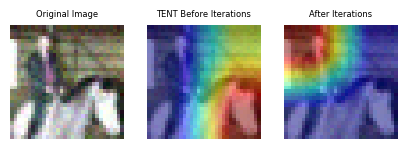

Starting off with Elastic Transform at a low corruption severity of 1, we can see that TENT refocuses on the image of the positioning of the cat. While it's not perfect, it would likely get better after more iterations.

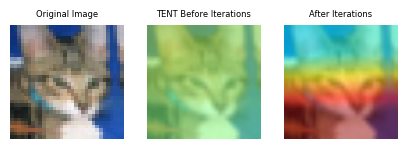

<!-- At Gaussian Noise level 3, the location of the duck is identified post-TENT iterations:

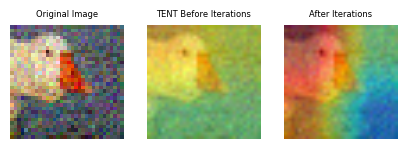 -->

At Gaussian Noise level 3, the location of the boat is identified here after post-TENT iterations:

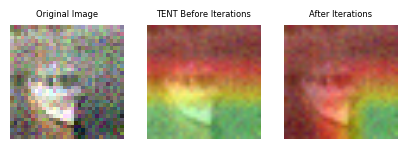

At Defocus Blur Level 3, before TENT, the pixelation results in a strange top-half focus of the truck, primarily focusing on the sky. Post-TENT, the visual focus warps to focus on the truck.

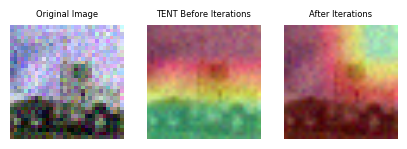

At Brightness Level 3, the head of the horse and it's legs are correctly identified here, as opposed to a generic blue-green washing pre-TENT

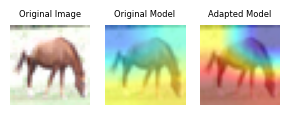

#### Confounding Cases

However, in certain cases, either nothing happens or the saliency map gets more indiscernible, often resulting in a 
wrong prediction. 

The otherwise logical identification of the animal is washed away post-adaptation.

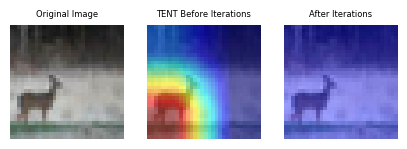

This saliency of a deer went from being some logical to simply covering half the image:

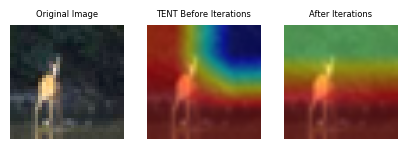

<!-- At Contrast Level 3, the image of a frog is completely green-washed:

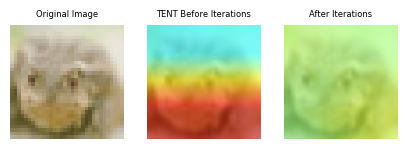 -->

At Contrast Level 3, the image of the grasshopper is completely red-washed:

<img src="./images/cropped_grasshopper.png" width="400">

<!-- At Zoom Blur Level 1, there is no change for this image of a truck:

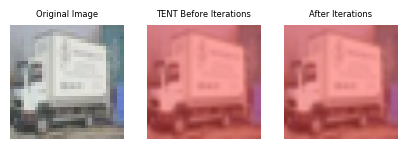 -->

<!-- At Zoom Blur Level 1, The half that contains the cat is identified:

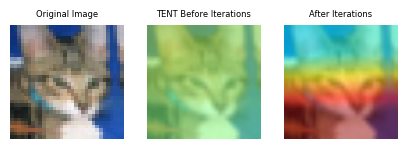 -->

General findings based on the visual heatmaps and why this experiment was not as meaningful as I expected:

- In the cases where TENT works, the saliency map often starts focusing on the object of interest or the head/distinguishing feature of the object. 
- I find that visual saliency is still a very limited way to understand the change in the model's understanding, because saliency maps are not guaranteed to align perfectly with human intuition. The “before” map may look more logical to us (like the head of an animal) because it highlights the object shape.
- CIFAR images are extremely low resolution, so pixel densities are low and there is only limited information we can observe. Furthermore, this is also the reason the saliency map is not as profound. 
- To truly understand the change in the affine parameters during backpropagation, I logged out the values before and after an optimizer step, and found that the change in the statistical distribution was proportional to the batch size of the images on which the new statistics are computed. This aligns with the intuition of the entropy minimization principle in the TENT paper, where batch size is a crucial hyperparameter.

# [Experiment 3, 4, 5](exp-3):  Exploring Forward-Only Adaptation and the Possibilites of Hybrid Gradient-Free & Gradient-Based Methods

> While this experiment has been split into parts, each approach can be considered a part of the same overarching experiment, with the end goal being comparing the 3 approaches.

The state-of-the-art test-time adaptation method is forward-only adaptation (FOA). The authors argue that past work that requires backpropagation during test-time is unsuitable for edge, low-resource deployments. 

FOA works by adding additional prompts to sequence-based models (like the ViT) and learns them via a derivative-free evolutionary covariance matrix adaptation strategy. 

<p align="center">
<img src="./images/foa.png" width="500">
</p>

However, a key shortcoming of forward-only adaptation is that it suffers under extreme distribution shifts, because it doesn't explicitly neurally update the model. 

This experiment tries to probe the foundations of FOA and sees if a hybrid model that combines gradient-free and gradient-based methods can be used to improve performance under extreme distribution shifts. If that is the case, these models will be computationally analysed to understand the performance-complexity trade-off and ways this can be optimised further for edge deployments. 

There are 3 approaches I build and compare the computational complexity of each of the models:

1. FOA alone - Covariance Matrix Adaptation
2. FOA + TENT - Covariance Matrix Adaptation + Entropy Minimisation
3. FOA + TTT - Covariance Matrix Adaptation + Auxiliary Task Test-Time Training (Sun et al., 2020)'s - I put my own twist on the approach by proposing an auxiliary model that can be hosted in the server, receving test images in batches and periodically sending updates back to the main model. 

**To the best of my knowledge, this is the first work to combine gradient-free and gradient-based methods for test-time adaptation, compare their computational complexity and analyse the trade-offs for edge deployments.**

<!-- For simplicity, TTT (Sun et al., 2020) is chosen as the gradient-based method. I am using TTT instead of TENT here because the FOA paper already tested FOA+TENT and found  The main model is a combination is a ViT equipped with covariance matrix adaptation.  -->

### Methodology

To scope the distribution shifts simulated, I choose 5 corruptions and the highest severity level of 5 from CIFAR-10-C, and ran it through the following steps:

1. Finetune the ViT on CIFAR-10 (*since the ViT was originally trained on ImageNet*)
2. Load CIFAR-10 weights into the ResNet
3. Jointly train the ViT-ResNet setup on CIFAR-10
4. Do Forward-Only Adaptation (Using the Covariance Matrix) alone on the ViT
5. Do Forward-Only Adaptation + Auxiliary Task 
6. Do Forward-Only Adaptation + TENT
7. Run every single model on 5 different corruptions
8. Compare and contrast the results and computational complexities
9. Discuss possible optimisation approaches and future work to see how we can further optimise the best performing model.

For fairness, all models are trained on an NVIDIA Tesla T4 GPU on Lightning AI. In cases where hyperparameters, such as weighting factors are unclear, hyperparameter tuning is done. Otherwise, we use the default hyperparameters outlined in the paper.

### Approach 1 - Forward-Only Adaptation (FOA)

Exact implementation of the Forward-Only Adaptation based on the paper. 

<p align="center">
    <img src="./excalidraw_graphics/foa.png" width=600 />
</p>

Find implementation code in the [raw_exp3_part1.ipynb](raw_exp3_part1.ipynb) notebook.

### Approach 2 - Forward Only Adaptation (FOA) + Test-Time Entropy Minimization (TENT)

Combining Forward-Only Adaptation with the TENT method that was experimented with earlier. This approach employs loss functions that simultaneously update the covariance matrix and the affine parameters of the batch normalization layers.

<p align="center">
    <img src="./excalidraw_graphics/foa_tent.png" width=600 />
</p>

Find implementation code in [raw_exp3_part2.ipynb](raw_exp3_part2.ipynb) notebook. 

The class of the proposed FOA-TENT algorithm can be found in [./tta_library/foa_tent.py](./tta_library/foa_tent.py).

### Approach 3 - Forward Only Adaptation (FOA) + TTT (Test-Time Training)

Use both a ViT and a ResNet and backpropagate learnings from the auxiliary ResNet to the ViT. This would be similar to a teacher-student model, and is effectively de-coupled (Hinton et al., 2015). An auxiliary task such as rotation prediction is chosen here, with inspiration from the original TTT paper from Sun et al. (2020). However, unlike the original TTT paper that used a shared backbone feature extractor, I put my own twist on this approach by adopting a teacher-student decoupled model, where the teacher is the auxiliary model and the student is the main model, with the former being a ResNet and the latter being a ViT.

<p align="center">
    <img src="./excalidraw_graphics/foa_ttt.png" width=600 />
</p>

I also test 2 approaches of jointly training the main model and the self-supervised model. Namely, I use the auxiliary loss to either backpropagate on the entire main model or only the last ViT block. This combines the experimental setups of Sun et al. (2020) and Niu et al. (2024) and the hyperparameter setup by Gandelsman et al. (2024), who proposed a probing-based training method for ViT. Backpropagating on the entire model resulted in very noisy losses, with the learned representations of the ViT being significantly altered - this caused the FOA + TTT approach to have worse performance than the original FOA baseline. Backpropagating only on the last block resulted in more stable losses and better performance.

The papers primarily used ImageNet-C for their experiments, but I've modified the architectures for CIFAR-10-C. To ensure fairness, I use CIFAR-pretrained weights for the ResNet and I first fine-tune the ViT on CIFAR-10 before plugging it into the setup. 

Find implementation code in [raw_exp3_part3.ipynb](raw_exp3_part3.ipynb) notebook. 

### Results

<p>
<img src="./images/performance_each_variant_corruption.png" width="500">
</p>

<!-- |                       |    FOA |   FOA + TTT |   FOA + TENT |
|:----------------------|-------:|------------:|-------------:|
| defocus_blur_level_5  | 0.7565 |      0.7602 |       0.876  |
| shot_noise_level_5    | 0.4177 |      0.4569 |       0.7223 |
| glass_blur_level_5    | 0.6247 |      0.6391 |       0.7755 |
| motion_blur_level_5   | 0.7298 |      0.7385 |       0.8638 |
| impulse_noise_level_5 | 0.4599 |      0.4754 |       0.7024 | -->

|                       |    FOA  |   FOA + TTT | % Improvement (TTT vs FOA) |   FOA + TENT | % Improvement (TENT vs FOA) |
|:----------------------|--------:|------------:|---------------------------:|-------------:|----------------------------:|
| defocus_blur_level_5  | 0.7565  |      0.7602 |                     0.49%  |       0.8760 |                     14.64%  |
| shot_noise_level_5    | 0.4177  |      0.4569 |                     8.96%  |       0.7223 |                     53.44%  |
| glass_blur_level_5    | 0.6247  |      0.6391 |                     2.27%  |       0.7755 |                     21.54%  |
| motion_blur_level_5   | 0.7298  |      0.7385 |                     1.20%  |       0.8638 |                     16.82%  |
| impulse_noise_level_5 | 0.4599  |      0.4754 |                     3.31%  |       0.7024 |                     41.73%  |


Under all corruptions, the hybrid FOA + TENT outperforms both plain FOA and FOA + TTT from a pure accuracy, error and ECE standpoint. We can take this analysis deeper by analysing the computational complexity and average runtimes to analyse the trade-off between the model and backpropagation complexity, and the performance gains. 

| Model | Trainable Params *(During Inference)* | MACs During Backprop | Key Computations |
|-------|---------------------------------------|-----------------------------| ----------------- |
| FOA | 0 (only prompts are tuned, there's no backprop) | 0 (CMA matrix update excluded) | Covariance Matrix Adaptation |
| FOA + TENT | 9600 (ViT $BN$ Affine Parameters) | 66M (Affine Parameters Alone) | Covariance Matrix Adaptation + Entropy Minimisation |
| FOA + TTT | 444864 (Last Transformer Block) + 2M (ResNet on server) = 6.48M | 203.24M (Last Transformer Block) + 2.06M (ResNet on server) = 205.3M | Covariance Matrix Adaptation + Auxiliary Model Backpropagation |

### Analysis So Far

- FOA Alone has minimal computational overhead, since by design, it requires zero backpropagation. It is also the fastest model to train and infer from, as the only computation is the evolutionary algorithm that updates the prompts.

- FOA + TENT produces significant accuracy gains with a relatively small subset of the trainable parameters. However, it requires some moderate additional computation to update the affine parameters of the batch normalisation layers, but this is extremely modest compared to a full backpropagation of such a huge network. 

- FOA + TTT offers very minimal accuracy and error improvements over plain FOA, but this is not nearly as high as FOA + TENT. There is also a significantly higher computational burden in this design because it requires server coordination to regulate periodic backpropagation between the ResNet on the server and the ViT on the edge device. This architecture has several limitations, including the need for separate backbones (ViT for the main task, and ResNet for the auxiliary task). My original hypothesis was that the convolutional information learned via the ResNet would enrich the ViT's understanding. This doesn't seem to be the case -- future work could explore sharing the same backbone for both tasks. 

### Deeper Analysis at a Lower Corruption Level

I took the best performing model (FOA + TENT) and ran it at a moderate corruption level of 3, and compared the result to plain FOA, to see whether the improvement is consistent even at a lower corruption level. 

|                       |    FOA |   FOA + TENT | % Improvement |
|:----------------------|-------:|-------------:|--------------:|
| defocus_blur_level_3  | 0.7394 |       0.9318 | 23.03%       |
| shot_noise_level_3    | 0.5449 |       0.818  | 40.08%       |
| motion_blur_level_3   | 0.6661 |       0.8853 | 28.26%       |
| glass_blur_level_3    | 0.6027 |       0.845  | 33.47%       |
| impulse_noise_level_3 | 0.5837 |       0.8562 | 37.85%       |

The improvements are slightly less profound at a lower corruption level, showing that these hybrid approaches are most effective under extreme distribution shifts. Engineers should take note of this trade-off when designing production TTA systems deployed on edge. 

# Conclusion

This work explored the foundations of test-time adaptation, with a focus on model compression (via structured pruning) and limited computational resources. Models were adapted during inference to handle corruptions, and evaluated both statistically (accuracy, ECE, SSIM) and visually (saliency images) for insight into their internal changes. 

Results show that TTA can recover performance when models face distribution shifts, even in constrained settings, and often outperform unadapted models after moderate $\rightarrow$ severe pruning. SSIM analysis of the heatmaps also revealed that adaptation shifts model attention in mostly meaningful ways; although this direction of probing might be suboptimal due to the naivety of salience maps and the difference between a human's perception of importance in an image and a model's. It was nevertheless interesting.

The last part of the project tried to computationally analyse novel hybrid approaches to test-time adaptation, that combine gradient-free and gradient-based methods. It tried to test the hypothesis that backpropagation would in fact deliver performance returns so profound that it makes the computational overhead worth it. This did seem to be the case, and I hope that these designs can help future researchers develop more optimised TTA deployments under edge settings. 

Future Work:
1. Further optimising the FOA + TENT model via pruning to reduce the overhead of the vision transformer. 
2. Incorporating the student-teacher paradigm from FOA + TTT into FOA + TENT to see if the affine parameter updates can be done periodically and propagated downwards to the main ViT for a more optimised setup.
3. Building a proper server setup that decides when to backpropagate and when to update the covariance matrix, to ensure that the model runs at it's optimal state.

## References

1. Wang, D., Shelhamer, E., Liu, S., Olshausen, B., & Darrell, T. (2020). Tent: Fully test-time adaptation by entropy minimization. arXiv preprint arXiv:2006.10726.
2. Sun, Y., Wang, X., Liu, Z., Miller, J., Efros, A.A., & Hardt, M. (2019). Test-Time Training for Out-of-Distribution Generalization. ArXiv, abs/1909.13231.
3. Niu, S., Miao, C., Chen, G., Wu, P., & Zhao, P. (2024). Test-time model adaptation with only forward passes. arXiv preprint arXiv:2404.01650.
4. Fang, G., Ma, X., Song, M., Mi, M.B., & Wang, X. (2023). DepGraph: Towards Any Structural Pruning. 2023 IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR), 16091-16101.
5. Daniel Hendrycks. (2019). CIFAR-10-C and CIFAR-10-P. https://doi.org/10.5281/zenodo.2535967
6. Hendrycks, D., & Dietterich, T. (2019). Benchmarking Neural Network Robustness to Common Corruptions and Perturbations. Proceedings of the International Conference on Learning Representations.
7. Liang, J., He, R., & Tan, T. (2024). A Comprehensive Survey on Test-Time Adaptation Under Distribution Shifts. International Journal of Computer Vision, 133(1), 31-64.
8. Hinton, G., Vinyals, O., & Dean, J. (2015). Distilling the Knowledge in a Neural Network. ArXiv.
9. Gildeblat, J. (2021). PyTorch library for CAM methods.